# OTOC oscillations in open quantum systems

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from otoc_open import OTOC
import numpy as np
import matplotlib.pyplot as plt

We consider the following Hamiltonian:

$H = -J \sum_{i=0}^{L-2} \sigma_i^z \sigma_{i+1}^z + \sum_{i=0}^{L-1} (h_x \sigma_i^x + h_z \sigma_i^z) $

In the inifinite temperature limit, the OTOC for the spin chain is given by: 

$C^{\mu\nu}_{ij}(t) = \frac{1}{2}<[\sigma^{\mu}_i(t),\sigma^{\nu}_j]^2> = 1-\Re\{\text{Tr}[\sigma^{\mu}_i(t)\sigma^{\nu}_j\sigma^{\mu}_i(t)\sigma^{\nu}_j]\}/D$,

where $D$ is the dimension of the Hilbert space.

## Closed system (unitary dynamics)

Here, I am reproducing the results of the paper [*Signatures of quantum chaos transition in short spin chains*](https://arxiv.org/pdf/2004.14440). I set $J=1$, $h_x=1$, $h_z=0$ and consider the OTOC $C^{ZX}_{03}(t)$ for a spin chain of length $L=4$.

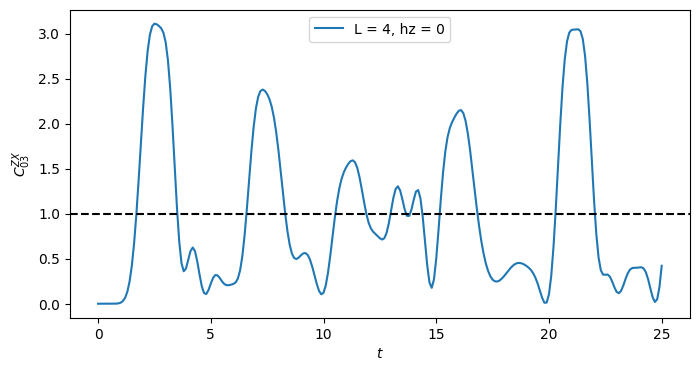

In [4]:
otoc = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='unitary')

otoc.analysis()
otoc.plot_otoc()

Now this time, $h_z = 0.5$ (chaotic regime). 

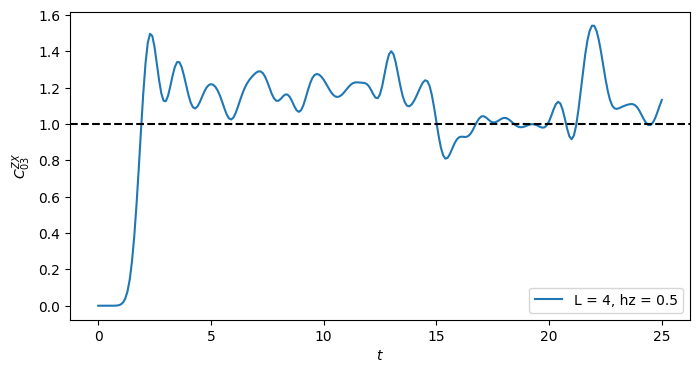

In [5]:
otoc = OTOC.init(L=4, J=1, hz=0.5, hx=1, mu='Z', nu='X', i=0, j=3, T=25, tstep=0.1, Dt=10, init_state=0, dynamics='unitary')

otoc.analysis()
otoc.plot_otoc()

## Open system

The quantity that we examine in closed systems was the following:

$$C^{\mu\nu}_{ij}(t) = \frac{1}{2}<[\sigma^{\mu}_i(t),\sigma^{\nu}_j]^2> = 1-\Re\{\text{Tr}[\sigma^{\mu}_i(t)\sigma^{\nu}_j\sigma^{\mu}_i(t)\sigma^{\nu}_j \rho_S]\}$$

Following the method used in [*Information scrambling in chaotic systems with dissipation*](https://arxiv.org/pdf/1802.04492), the analogous quantity in open systems is:

$$1-F(t, \sigma^{\mu}_i, \sigma^{\nu}_j) \equiv 1-\mathfrak{R} \text{tr} \left( \left[ e^{\mathcal{L}_b^\dagger t} \cdot (\sigma^{\nu}_j)^\dagger \right] \cdot \sigma^{\mu}_i \cdot \left[ e^{\mathcal{L}_f t} \cdot (\sigma^{\nu}_j \rho_s(0)) \right] \cdot (\sigma^{\mu}_i)^\dagger \right)$$

where $\mathcal{L}_f \cdot \rho = -i[H_s, \rho] + \sum_{k} \frac{\Gamma}{2} (2L_k \rho L_k^\dagger - \{L_k^\dagger L_k, \rho\})$ and $\mathcal{L}_b \cdot \rho = +i[H_s, \rho] + \sum_{k} \frac{\Gamma}{2} (2L_k \rho L_k^\dagger - \{L_k^\dagger L_k, \rho\})$. The important thing is that we define $H_f = H_s + H_e + H_{int}$ and $H_b = -H_s + H_e + H_{int}$. This $H_b$ is different from the "naive" time-reversal Hamiltonian $H_b' = -H_f$! Correspondingly, the backward evolution map, $e^{\mathcal{L}_b t}$, is not equivalent to the inverse of the forward map, $e^{-\mathcal{L}_f t}$.


Also, strictly speaking, this quantity is no longer equal to $C^{\mu\nu}_{ij}(t) = \frac{1}{2}<[\sigma^{\mu}_i(t),\sigma^{\nu}_j]^2>$, but still we can calculate that quantity. In the limit of the damping parameter going to zero (unitary limit), the above expression is exactly equal to $C^{\mu\nu}_{ij}(t)$.

The below shows the results for dephasing dynamics $L_k = \sqrt{\kappa} \sigma_k^z$ with $\kappa=0.1$.

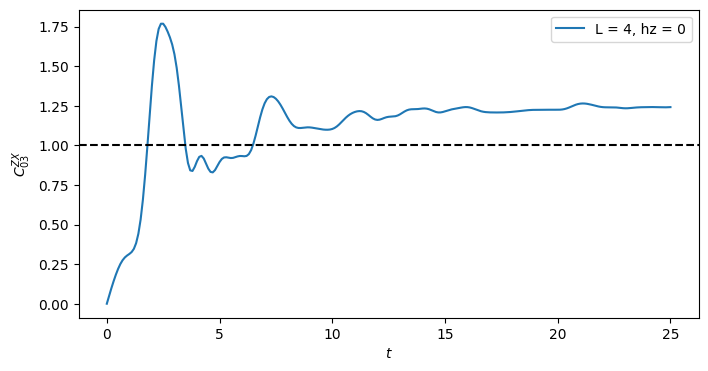

In [14]:
otoc = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='boundary', direction='Z')
otoc.analysis()
otoc.plot_otoc()

As you can see, the oscillations are decaying, but this is not due to the scrambling effect, rather it is because the information is leaking to the environment. In the reference paper, in order to eliminate such an effect, the authors proposed the idea to devide $F(t, \sigma^{\mu}_i, \sigma^{\nu}_j)$ by $F(t, I, \sigma^{\nu}_j)$, which is a factor representing the overall decay of quantum information due to leaking only.

Therefore, the normalized OTOC can defined as:
$$1 - \frac{F(t, \sigma^{\mu}_i, \sigma^{\nu}_j)}{F(t, I, \sigma^{\nu}_j)}$$

In [15]:
otoc1 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='unitary')
otoc1.analysis()
otoc2 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='boundary', direction='Z')
otoc2.analysis()
otoc3 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='boundary', direction='Z')
otoc3.analysis_normalized()

Here is the plot of the OTOCs of both closed and open systems (normalized + unnormalized).

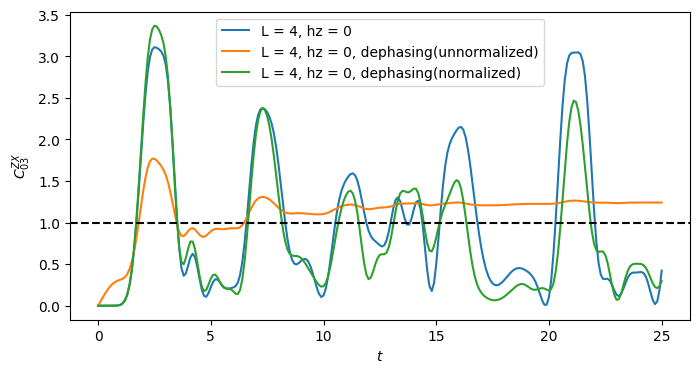

In [16]:
plt.figure(figsize=(8,4))
plt.plot(otoc1.tlist,otoc1.normalized_otoc_list, label = f'L = {otoc1.mfim.L}, hz = {otoc1.mfim.hz}')
plt.plot(otoc2.tlist,otoc2.normalized_otoc_list, label = f'L = {otoc2.mfim.L}, hz = {otoc2.mfim.hz}, dephasing(unnormalized)')
plt.plot(otoc3.tlist,otoc3.normalized_otoc_list, label = f'L = {otoc3.mfim.L}, hz = {otoc3.mfim.hz}, dephasing(normalized)')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel(rf"$C^{{{otoc1.mu}{otoc1.nu}}}_{{{otoc1.i}{otoc1.j}}}$")
plt.legend()
plt.show()

Different examples

$h_z = 0.5$ (chaotic regime), dephasing on the boundary spins, $\kappa = 0.1$

In [17]:
otoc1 = OTOC.init(L=4, J=1, hz=0.5, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='unitary')
otoc1.analysis()
otoc2 = OTOC.init(L=4, J=1, hz=0.5, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='boundary', direction='Z')
otoc2.analysis()
otoc3 = OTOC.init(L=4, J=1, hz=0.5, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='boundary', direction='Z')
otoc3.analysis_normalized()

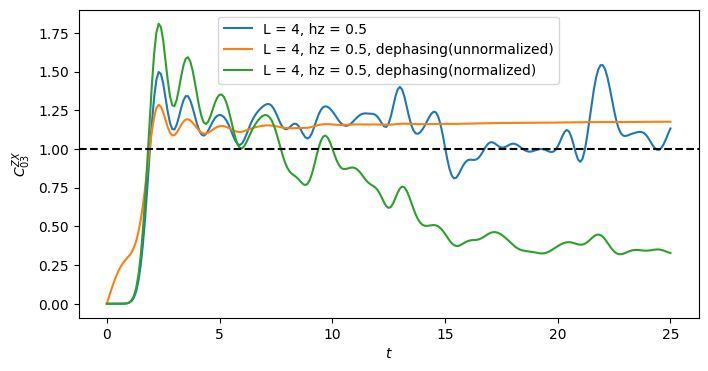

In [18]:
plt.figure(figsize=(8,4))
plt.plot(otoc1.tlist,otoc1.normalized_otoc_list, label = f'L = {otoc1.mfim.L}, hz = {otoc1.mfim.hz}')
plt.plot(otoc2.tlist,otoc2.normalized_otoc_list, label = f'L = {otoc2.mfim.L}, hz = {otoc2.mfim.hz}, dephasing(unnormalized)')
plt.plot(otoc3.tlist,otoc3.normalized_otoc_list, label = f'L = {otoc3.mfim.L}, hz = {otoc3.mfim.hz}, dephasing(normalized)')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel(rf"$C^{{{otoc1.mu}{otoc1.nu}}}_{{{otoc1.i}{otoc1.j}}}$")
plt.legend()
plt.show()

Normalized OTOC is decaying... Maybe just a numerical artifact of $F(t, I, \sigma^{\nu}_j)$?

$h_z = 0.0$ (integrable regime), dephasing on all spins, $\kappa = 0.1$

In [20]:
otoc1 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='unitary')
otoc1.analysis()
otoc2 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='bulk', direction='Z')
otoc2.analysis()
otoc3 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='dephasing', kappa=0.1, location='bulk', direction='Z')
otoc3.analysis_normalized()

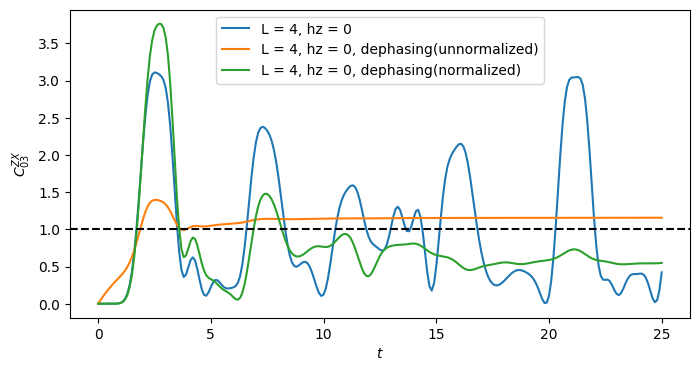

In [21]:
plt.figure(figsize=(8,4))
plt.plot(otoc1.tlist,otoc1.normalized_otoc_list, label = f'L = {otoc1.mfim.L}, hz = {otoc1.mfim.hz}')
plt.plot(otoc2.tlist,otoc2.normalized_otoc_list, label = f'L = {otoc2.mfim.L}, hz = {otoc2.mfim.hz}, dephasing(unnormalized)')
plt.plot(otoc3.tlist,otoc3.normalized_otoc_list, label = f'L = {otoc3.mfim.L}, hz = {otoc3.mfim.hz}, dephasing(normalized)')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel(rf"$C^{{{otoc1.mu}{otoc1.nu}}}_{{{otoc1.i}{otoc1.j}}}$")
plt.legend()
plt.show()

$h_z = 0.0$ (integrable regime), amplitude damping on the boundary spins, $\gamma = 0.1$ and $n_{\text{th}}=1$

Note that in amplitude damping, $L_1 = \sqrt{\gamma (n_{\text{th}}+1)}\,\sigma_{-}, \quad L_2 = \sqrt{\gamma n_{\text{th}}}\,\sigma_{+}$

In [22]:
otoc1 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='unitary')
otoc1.analysis()
otoc2 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='amplitude_damping', gamma=0.1, n_th=1, location='boundary')
otoc2.analysis()
otoc3 = OTOC.init(L=4, J=1, hz=0, hx=1, mu='Z', nu='X', i=0, j=3,T=25, tstep=0.1, Dt=10, init_state=0, dynamics='amplitude_damping', gamma=0.1, n_th=1, location='boundary')
otoc3.analysis_normalized()

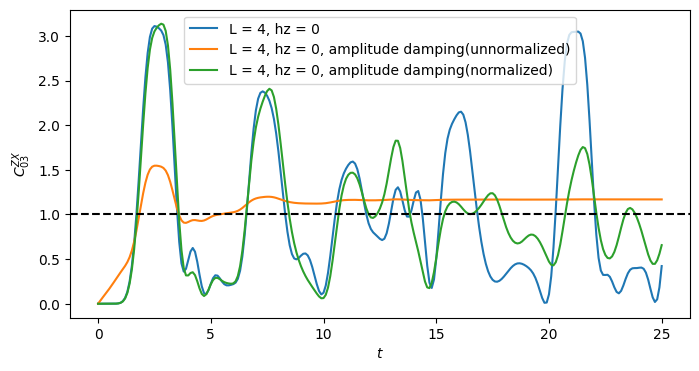

In [23]:
plt.figure(figsize=(8,4))
plt.plot(otoc1.tlist,otoc1.normalized_otoc_list, label = f'L = {otoc1.mfim.L}, hz = {otoc1.mfim.hz}')
plt.plot(otoc2.tlist,otoc2.normalized_otoc_list, label = f'L = {otoc2.mfim.L}, hz = {otoc2.mfim.hz}, amplitude damping(unnormalized)')
plt.plot(otoc3.tlist,otoc3.normalized_otoc_list, label = f'L = {otoc3.mfim.L}, hz = {otoc3.mfim.hz}, amplitude damping(normalized)')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel(rf"$C^{{{otoc1.mu}{otoc1.nu}}}_{{{otoc1.i}{otoc1.j}}}$")
plt.legend()
plt.show()